# Radar sensor simulation with the current ASAM OSI (v3.8.0)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Wedge

from osi3 import (
    osi_featuredata_pb2,
    osi_sensordata_pb2,
    osi_sensorview_pb2,
    osi_sensorviewconfiguration_pb2,
)
from osi_hfss import toy_env
from osi_hfss.toy_env import SPEED_OF_LIGHT

print("OSI interface version:", toy_env.interface_version())

OSI interface version: version_major: 3
version_minor: 8
version_patch: 0



### 1. `SensorViewConfiguration` — what the sensor model requests

2353 entries per diagram


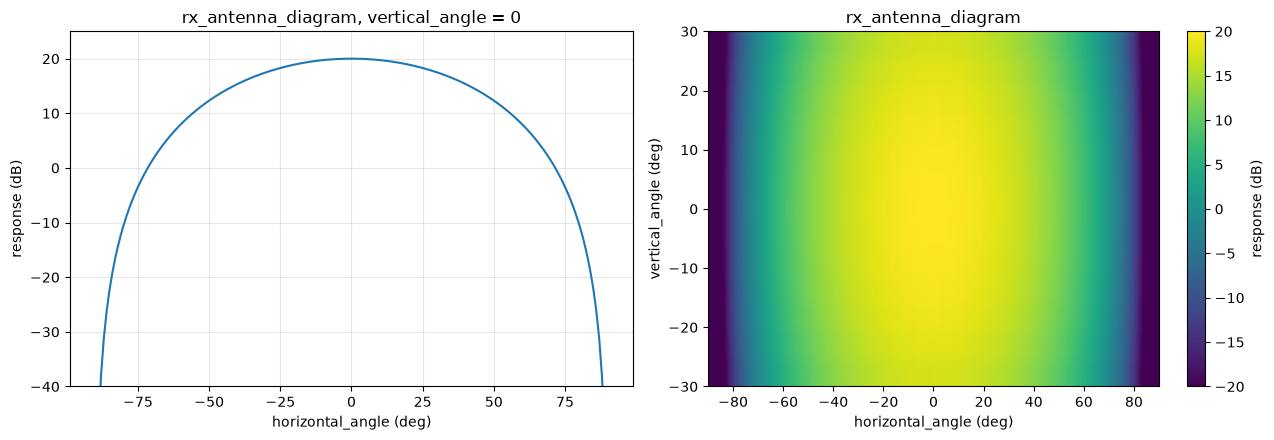

In [2]:
SENSOR_ID = 100
FREQUENCY = 77e9

sensor_view_configuration = osi_sensorviewconfiguration_pb2.SensorViewConfiguration()
sensor_view_configuration.version.CopyFrom(toy_env.interface_version())
sensor_view_configuration.sensor_id.value = SENSOR_ID
sensor_view_configuration.mounting_position.position.x = 3.5
sensor_view_configuration.mounting_position.position.z = 0.5
sensor_view_configuration.field_of_view_horizontal = np.radians(120.0)
sensor_view_configuration.field_of_view_vertical = np.radians(20.0)

radar_config = sensor_view_configuration.radar_sensor_view_configuration.add()
radar_config.sensor_id.value = SENSOR_ID
radar_config.mounting_position.CopyFrom(sensor_view_configuration.mounting_position)
radar_config.field_of_view_horizontal = np.radians(120.0)
radar_config.field_of_view_vertical = np.radians(20.0)
radar_config.number_of_rays_horizontal = 256
radar_config.number_of_rays_vertical = 16
radar_config.max_number_of_interactions = 1
radar_config.emitter_frequency = FREQUENCY

diagram_h = np.radians(np.arange(-90.0, 90.1, 1.0))
diagram_v = np.radians(np.arange(-30.0, 30.1, 5.0))


def cos2_response_db(h, v, peak_gain_db=20.0, floor_db=-60.0):
    linear = np.cos(h) ** 2 * np.cos(v) ** 2
    return peak_gain_db + np.maximum(20.0 * np.log10(np.maximum(linear, 1e-12)), floor_db - peak_gain_db)


for diagram in (radar_config.tx_antenna_diagram, radar_config.rx_antenna_diagram):
    for h in diagram_h:
        for v in diagram_v:
            diagram.add(horizontal_angle=h, vertical_angle=v, response=cos2_response_db(h, v))

print(f"{len(radar_config.tx_antenna_diagram)} entries per diagram")

response = np.array([e.response for e in radar_config.rx_antenna_diagram]).reshape(len(diagram_h), len(diagram_v))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))
ax0.plot(np.degrees(diagram_h), response[:, len(diagram_v) // 2])
ax0.set_title("rx_antenna_diagram, vertical_angle = 0")
ax0.set_xlabel("horizontal_angle (deg)")
ax0.set_ylabel("response (dB)")
ax0.set_ylim(-40, 25)
ax0.grid(True, alpha=0.3)
im = ax1.imshow(response.T, origin="lower", aspect="auto", vmin=-20, vmax=20,
                extent=[-90, 90, np.degrees(diagram_v[0]), np.degrees(diagram_v[-1])])
ax1.set_title("rx_antenna_diagram")
ax1.set_xlabel("horizontal_angle (deg)")
ax1.set_ylabel("vertical_angle (deg)")
fig.colorbar(im, ax=ax1, label="response (dB)")
plt.tight_layout()
plt.show()

### 2. `GroundTruth` — the scene

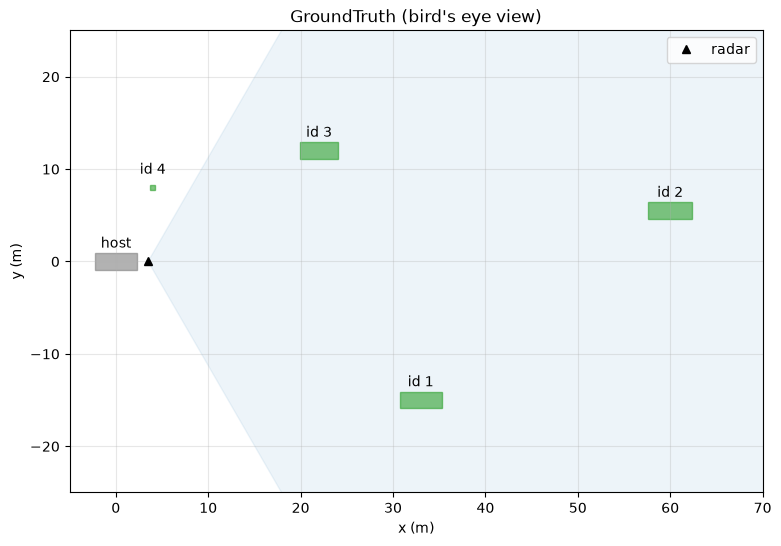

In [3]:
ground_truth = toy_env.make_ground_truth()


def plot_scene(ax, ground_truth, config):
    mount = config.mounting_position.position
    half_fov = np.degrees(config.field_of_view_horizontal / 2)
    ax.add_patch(Wedge((mount.x, mount.y), 80, -half_fov, half_fov, alpha=0.08, color="tab:blue"))
    for obj in ground_truth.moving_object:
        b = obj.base
        host = obj.id.value == ground_truth.host_vehicle_id.value
        ax.add_patch(Rectangle((b.position.x - b.dimension.length / 2, b.position.y - b.dimension.width / 2),
                               b.dimension.length, b.dimension.width,
                               color="tab:gray" if host else "tab:green", alpha=0.6))
        ax.annotate("host" if host else f"id {obj.id.value}", (b.position.x, b.position.y + 1.5), ha="center")
    ax.plot(mount.x, mount.y, "k^", label="radar")
    ax.set_xlim(-5, 70)
    ax.set_ylim(-25, 25)
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.grid(True, alpha=0.3)


fig, ax = plt.subplots(figsize=(10, 6))
plot_scene(ax, ground_truth, radar_config)
ax.set_title("GroundTruth (bird's eye view)")
ax.legend()
plt.show()

### 3. Environment simulation → `SensorView`

In [4]:
sensor_view = osi_sensorview_pb2.SensorView()
sensor_view.version.CopyFrom(toy_env.interface_version())
sensor_view.timestamp.CopyFrom(ground_truth.timestamp)
sensor_view.sensor_id.value = SENSOR_ID
sensor_view.mounting_position.CopyFrom(radar_config.mounting_position)
sensor_view.host_vehicle_id.CopyFrom(ground_truth.host_vehicle_id)
sensor_view.global_ground_truth.CopyFrom(ground_truth)

radar_sensor_view = sensor_view.radar_sensor_view.add()
radar_sensor_view.view_configuration.CopyFrom(radar_config)
radar_sensor_view.reflection.extend(toy_env.legacy_reflections(radar_config, ground_truth))

print(f"{'signal [dB]':>12} {'ToF [ns]':>9} {'doppler [Hz]':>13} {'h [deg]':>8} {'v [deg]':>8}")
for r in radar_sensor_view.reflection:
    print(f"{r.signal_strength:12.1f} {r.time_of_flight * 1e9:9.1f} {r.doppler_shift:13.0f} "
          f"{np.degrees(r.source_horizontal_angle):8.1f} {np.degrees(r.source_vertical_angle):8.1f}")

 signal [dB]  ToF [ns]  doppler [Hz]  h [deg]  v [deg]
       -96.0     220.8          2289    -27.0      0.0
       -99.5     378.7         -2556      5.6      0.0
       -93.0     147.1          8619     33.0      0.0


Across the simulator / FMU boundary OSI messages travel as serialised protobuf bytes.

In [5]:
payload = sensor_view.SerializeToString()
received_sensor_view = osi_sensorview_pb2.SensorView.FromString(payload)
assert received_sensor_view == sensor_view
print(f"SensorView: {len(payload) / 1e3:.1f} kB "
      f"(of which view_configuration: {radar_config.ByteSize() / 1e3:.1f} kB)")

del sensor_view, radar_sensor_view

SensorView: 137.2 kB (of which view_configuration: 136.5 kB)


### 4. Sensor model → `SensorData`

The sensor model receives the reflections and produces `RadarDetection`s in `SensorData.feature_data.radar_sensor`:

- `SNR = P_tx + signal_strength − P_noise`, detections below a threshold are dropped,
- range from `time_of_flight`, radial velocity from `doppler_shift`,
- RCS by inverting the radar equation with the known diagrams,
- **azimuth / elevation are copied from `source_*_angle`** — there is nothing in the interface that would allow the sensor model to *estimate* them (no per-channel phase).

In [6]:
TX_POWER_DBM = 12.0
NOISE_POWER_DBM = -110.0
SNR_THRESHOLD_DB = 10.0

received_config = received_sensor_view.radar_sensor_view[0].view_configuration

sensor_data = osi_sensordata_pb2.SensorData()
sensor_data.version.CopyFrom(toy_env.interface_version())
sensor_data.timestamp.CopyFrom(received_sensor_view.timestamp)
sensor_data.sensor_id.value = SENSOR_ID
sensor_data.mounting_position.CopyFrom(received_config.mounting_position)

radar_data = sensor_data.feature_data.radar_sensor.add()
radar_data.header.measurement_time.CopyFrom(received_sensor_view.timestamp)
radar_data.header.cycle_counter = 0
radar_data.header.sensor_id.value = SENSOR_ID
radar_data.header.mounting_position.CopyFrom(received_config.mounting_position)
radar_data.header.data_qualifier = osi_featuredata_pb2.SensorDetectionHeader.DATA_QUALIFIER_AVAILABLE

for reflection in received_sensor_view.radar_sensor_view[0].reflection:
    snr = TX_POWER_DBM + reflection.signal_strength - NOISE_POWER_DBM
    if snr < SNR_THRESHOLD_DB:
        continue
    h, v = reflection.source_horizontal_angle, reflection.source_vertical_angle
    distance = SPEED_OF_LIGHT * reflection.time_of_flight / 2
    antenna_db = (toy_env.diagram_lookup(received_config.tx_antenna_diagram, h, v)
                  + toy_env.diagram_lookup(received_config.rx_antenna_diagram, h, v))

    detection = radar_data.detection.add()
    detection.existence_probability = 1.0
    detection.position.distance = distance
    detection.position.azimuth = h  # copied, not estimated
    detection.position.elevation = v
    detection.radial_velocity = -reflection.doppler_shift * SPEED_OF_LIGHT / (2 * received_config.emitter_frequency)
    detection.snr = snr
    detection.rcs = (reflection.signal_strength - antenna_db
                     - toy_env.path_gain_db(received_config.emitter_frequency, 0.0, distance))

radar_data.header.number_of_valid_detections = len(radar_data.detection)

print(f"{'range [m]':>10} {'az [deg]':>9} {'v_r [m/s]':>10} {'rcs [dBsm]':>11} {'snr [dB]':>9}")
for d in radar_data.detection:
    print(f"{d.position.distance:10.2f} {np.degrees(d.position.azimuth):9.2f} "
          f"{d.radial_velocity:10.2f} {d.rcs:11.1f} {d.snr:9.1f}")

 range [m]  az [deg]  v_r [m/s]  rcs [dBsm]  snr [dB]
     33.09    -26.95      -4.46        10.0      26.0
     56.77      5.56       4.98        12.0      22.5
     22.05     32.97     -16.78         8.0      29.0


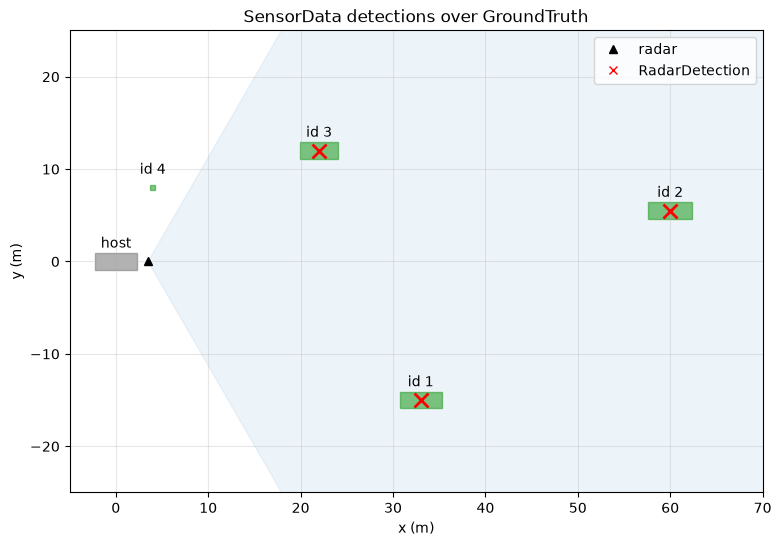

In [7]:
mount = received_config.mounting_position.position
fig, ax = plt.subplots(figsize=(10, 6))
plot_scene(ax, ground_truth, received_config)
for d in radar_data.detection:
    x = mount.x + d.position.distance * np.cos(d.position.azimuth)
    y = mount.y + d.position.distance * np.sin(d.position.azimuth)
    ax.plot(x, y, "rx", markersize=10, mew=2)
ax.plot([], [], "rx", label="RadarDetection")
ax.set_title("SensorData detections over GroundTruth")
ax.legend()
plt.show()

### 5. Why this is not enough for high-fidelity radar simulation

| needed for high fidelity | available in OSI v3.8.0 |
|---|---|
| complex (amplitude **and phase**) element pattern | scalar power diagram in dB |
| polarisation (co-/cross-polar, Jones matrix) | — |
| multiple Tx / Rx channels and their positions (MIMO, virtual array) | one Tx and one Rx diagram |
| antenna-free propagation channel, so the sensor model can apply its own antenna | antenna already folded into `signal_strength` |
| separate departure (Tx) and arrival (Rx) directions | `source_*_angle` only |
| polarimetric scattering of the target | — |

Consequently a sensor model cannot synthesise per-channel baseband signals and cannot run direction-of-arrival estimation, beamforming or polarimetric processing; the angle of a detection can only be copied from the reflection. `02_osi_hfss_antenna_extension.ipynb` proposes an extension that closes these gaps.